In [3]:
#Import and Load Prepared Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import (chi2, mutual_info_classif, 
                                       SelectKBest, f_classif)
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [4]:
#Recreate Clean Dataset from Phase 3

# Load data and apply all Phase 3 cleaning steps
df = pd.read_csv('../Dataset/covid.csv', low_memory=False)

# Create death column
df['death'] = df['date_died'].apply(lambda x: 1 if x == '9999-99-99' else 2)

# Keep only confirmed positive cases
df_positive = df[df['covid_res'] == 1].copy()

# Drop high-missing columns
drop_cols = ['id', 'entry_date', 'date_symptoms', 'date_died', 
             'covid_res', 'intubed', 'icu', 'pregnancy', 
             'contact_other_covid', 'patient_type']
df_clean = df_positive.drop(columns=drop_cols)

# Replace missing codes
missing_codes = [97, 98, 99]
feature_cols = ['sex', 'pneumonia', 'diabetes', 'copd', 'asthma', 
                'inmsupr', 'hypertension', 'other_disease', 'cardiovascular', 
                'obesity', 'renal_chronic', 'tobacco']

for col in feature_cols:
    df_clean[col] = df_clean[col].replace(missing_codes, np.nan)

df_clean['age'] = df_clean['age'].replace(missing_codes, np.nan)
df_clean.loc[df_clean['age'] > 110, 'age'] = np.nan

# Drop NaN rows
df_clean.dropna(inplace=True)

# Convert target
df_clean['death'] = df_clean['death'].map({1: 0, 2: 1})

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Features: {[col for col in df_clean.columns if col != 'death']}")

# Split
X = df_clean.drop(columns=['death'])
y = df_clean['death']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nBalanced training data shape: {X_train_smote.shape}")
print(f"Balanced target distribution:")
print(pd.Series(y_train_smote).value_counts())

Clean dataset shape: (218817, 14)
Features: ['sex', 'pneumonia', 'age', 'diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension', 'other_disease', 'cardiovascular', 'obesity', 'renal_chronic', 'tobacco']

Balanced training data shape: (307426, 13)
Balanced target distribution:
death
0    153713
1    153713
Name: count, dtype: int64


In [5]:
#Method 1:- Chi-Squared Test

# Chi-square measures dependency between categorical features and target
# Higher score = stronger association with death outcome

# All features are categorical (1=yes, 2=no) so chi2 is perfect
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_train_smote, y_train_smote)

chi2_scores = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Chi2_Score': chi2_selector.scores_,
    'Chi2_Rank': pd.Series(chi2_selector.scores_).rank(ascending=False)
}).sort_values('Chi2_Score', ascending=False)

print("="*60)
print("METHOD 1: CHI-SQUARE TEST")
print("="*60)
print(chi2_scores.to_string(index=False))
print("\nInterpretation: Higher score = stronger association with death")

METHOD 1: CHI-SQUARE TEST
       Feature    Chi2_Score  Chi2_Rank
           age 452097.793619        1.0
     pneumonia  18184.205400        2.0
  hypertension   2848.612118        3.0
      diabetes   2366.817376        4.0
           sex    666.999656        5.0
       obesity    138.020109        6.0
 renal_chronic     59.357492        7.0
          copd     22.790996        8.0
cardiovascular     18.897067        9.0
        asthma      9.154248       10.0
 other_disease      4.908928       11.0
       inmsupr      3.140046       12.0
       tobacco      0.542795       13.0

Interpretation: Higher score = stronger association with death


In [6]:
#Method 2:- Mutual Information

# Mutual information measures how much knowing a feature 
# reduces uncertainty about the target
# Works for both categorical and continuous (age)

mi_scores = mutual_info_classif(X_train_smote, y_train_smote, 
                                 random_state=42, n_neighbors=5)

mi_df = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'MI_Score': mi_scores,
    'MI_Rank': pd.Series(mi_scores).rank(ascending=False)
}).sort_values('MI_Score', ascending=False)

print("="*60)
print("METHOD 2: MUTUAL INFORMATION")
print("="*60)
print(mi_df.to_string(index=False))
print("\nInterpretation: Higher score = knowing this feature tells you more about death risk")

METHOD 2: MUTUAL INFORMATION
       Feature  MI_Score  MI_Rank
     pneumonia  0.220368      1.0
           age  0.163060      2.0
  hypertension  0.059364      3.0
      diabetes  0.058327      4.0
       inmsupr  0.029868      5.0
 renal_chronic  0.028147      6.0
 other_disease  0.026622      7.0
cardiovascular  0.025306      8.0
       obesity  0.025077      9.0
          copd  0.024356     10.0
        asthma  0.022326     11.0
       tobacco  0.022171     12.0
           sex  0.020314     13.0

Interpretation: Higher score = knowing this feature tells you more about death risk


In [7]:
#Method 3:- Random Forest Feature Importance

# Train RF and ask which features it relied on most
# This is data-driven - the model tells us what mattered

rf_importance = RandomForestClassifier(n_estimators=200, random_state=42, 
                                        max_depth=10, n_jobs=-1)
rf_importance.fit(X_train_smote, y_train_smote)

importance_df = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'RF_Importance': rf_importance.feature_importances_,
    'RF_Rank': pd.Series(rf_importance.feature_importances_).rank(ascending=False)
}).sort_values('RF_Importance', ascending=False)

print("="*60)
print("METHOD 3: RANDOM FOREST FEATURE IMPORTANCE")
print("="*60)
print(importance_df.to_string(index=False))
print("\nInterpretation: Higher importance = model used this more for predictions")

METHOD 3: RANDOM FOREST FEATURE IMPORTANCE
       Feature  RF_Importance  RF_Rank
     pneumonia       0.530269      1.0
           age       0.275305      2.0
  hypertension       0.062419      3.0
      diabetes       0.058472      4.0
 renal_chronic       0.014097      5.0
           sex       0.013903      6.0
       obesity       0.009947      7.0
          copd       0.008117      8.0
        asthma       0.006850      9.0
 other_disease       0.006418     10.0
       tobacco       0.005801     11.0
cardiovascular       0.004845     12.0
       inmsupr       0.003559     13.0

Interpretation: Higher importance = model used this more for predictions


In [8]:
#Combine all Three Methods

# Merge all three ranking methods
combined = chi2_scores[['Feature', 'Chi2_Score', 'Chi2_Rank']].merge(
    mi_df[['Feature', 'MI_Score', 'MI_Rank']], on='Feature'
).merge(
    importance_df[['Feature', 'RF_Importance', 'RF_Rank']], on='Feature'
)

# Calculate average rank across all three methods
combined['Avg_Rank'] = combined[['Chi2_Rank', 'MI_Rank', 'RF_Rank']].mean(axis=1)
combined = combined.sort_values('Avg_Rank')

print("="*90)
print("COMBINED FEATURE RANKING - ALL THREE METHODS")
print("="*90)
print(combined.to_string(index=False))

# Show top features
print("\n" + "="*60)
print("TOP 10 FEATURES BY AVERAGE RANK")
print("="*60)
top10 = combined.head(10)
print(top10[['Feature', 'Avg_Rank']].to_string(index=False))

# Paper used these 6
paper_features = ['age', 'sex', 'diabetes', 'obesity']
print(f"\n\nPaper's 4 features (excluding covid_result which is constant now):")
for feat in paper_features:
    if feat in combined['Feature'].values:
        rank = combined[combined['Feature'] == feat]['Avg_Rank'].values[0]
        print(f"  {feat}: Average rank {rank:.1f}")

COMBINED FEATURE RANKING - ALL THREE METHODS
       Feature    Chi2_Score  Chi2_Rank  MI_Score  MI_Rank  RF_Importance  RF_Rank  Avg_Rank
     pneumonia  18184.205400        2.0  0.220368      1.0       0.530269      1.0  1.333333
           age 452097.793619        1.0  0.163060      2.0       0.275305      2.0  1.666667
  hypertension   2848.612118        3.0  0.059364      3.0       0.062419      3.0  3.000000
      diabetes   2366.817376        4.0  0.058327      4.0       0.058472      4.0  4.000000
 renal_chronic     59.357492        7.0  0.028147      6.0       0.014097      5.0  6.000000
       obesity    138.020109        6.0  0.025077      9.0       0.009947      7.0  7.333333
           sex    666.999656        5.0  0.020314     13.0       0.013903      6.0  8.000000
          copd     22.790996        8.0  0.024356     10.0       0.008117      8.0  8.666667
 other_disease      4.908928       11.0  0.026622      7.0       0.006418     10.0  9.333333
cardiovascular     18.897

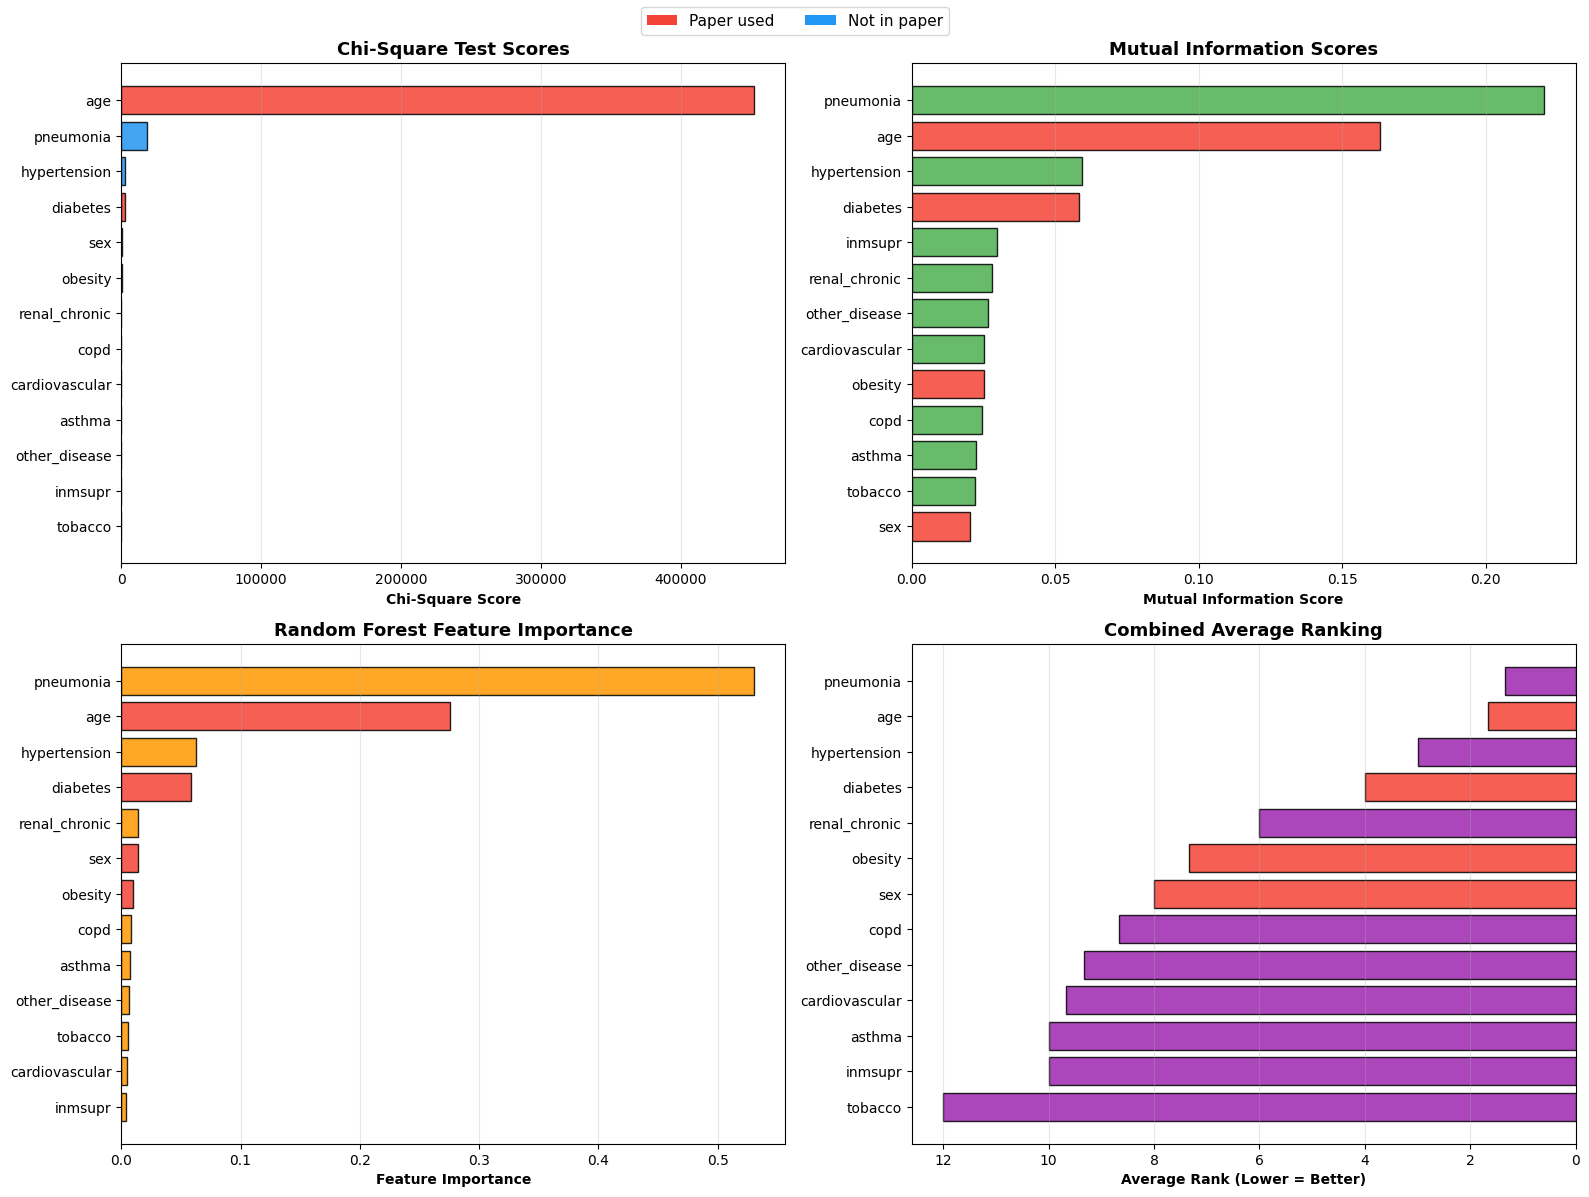

In [9]:
#Visualise Feature Rankings

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Chi-Square scores
ax1 = axes[0, 0]
colors1 = ['#F44336' if x in paper_features else '#2196F3' 
           for x in chi2_scores['Feature']]
bars1 = ax1.barh(chi2_scores['Feature'], chi2_scores['Chi2_Score'],
                 color=colors1, edgecolor='black', alpha=0.85)
ax1.set_xlabel('Chi-Square Score', fontweight='bold')
ax1.set_title('Chi-Square Test Scores', fontweight='bold', fontsize=13)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Mutual Information
ax2 = axes[0, 1]
colors2 = ['#F44336' if x in paper_features else '#4CAF50' 
           for x in mi_df['Feature']]
bars2 = ax2.barh(mi_df['Feature'], mi_df['MI_Score'],
                 color=colors2, edgecolor='black', alpha=0.85)
ax2.set_xlabel('Mutual Information Score', fontweight='bold')
ax2.set_title('Mutual Information Scores', fontweight='bold', fontsize=13)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Plot 3: RF Importance
ax3 = axes[1, 0]
colors3 = ['#F44336' if x in paper_features else '#FF9800' 
           for x in importance_df['Feature']]
bars3 = ax3.barh(importance_df['Feature'], importance_df['RF_Importance'],
                 color=colors3, edgecolor='black', alpha=0.85)
ax3.set_xlabel('Feature Importance', fontweight='bold')
ax3.set_title('Random Forest Feature Importance', fontweight='bold', fontsize=13)
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# Plot 4: Average Rank comparison
ax4 = axes[1, 1]
colors4 = ['#F44336' if x in paper_features else '#9C27B0' 
           for x in combined['Feature']]
bars4 = ax4.barh(combined['Feature'], combined['Avg_Rank'],
                 color=colors4, edgecolor='black', alpha=0.85)
ax4.set_xlabel('Average Rank (Lower = Better)', fontweight='bold')
ax4.set_title('Combined Average Ranking', fontweight='bold', fontsize=13)
ax4.invert_yaxis()
ax4.invert_xaxis()  # Lower rank is better
ax4.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F44336', label='Paper used'),
                   Patch(facecolor='#2196F3', label='Not in paper')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('phase4_feature_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
#Final Feature Selection Decision

# Select top N features based on average ranking
# We want more than the paper's 4, but not all 13

# Decision criteria:
# 1. Top 10 by average rank (systematic choice)
# 2. Must include high-impact chronic diseases from Phase 2 analysis
# 3. Age is mandatory (strongest predictor in all methods)

selected_features = combined.head(10)['Feature'].tolist()

print("="*70)
print("PHASE 4 - FINAL FEATURE SELECTION")
print("="*70)
print(f"\nSelected features (Top 10 by combined ranking):")
for i, feat in enumerate(selected_features, 1):
    avg_rank = combined[combined['Feature'] == feat]['Avg_Rank'].values[0]
    print(f"{i:2d}. {feat:<18} (Avg Rank: {avg_rank:.2f})")

print(f"\n\nComparison with original paper:")
print(f"Paper used: {paper_features}")
print(f"\nWe are using: {selected_features}")
print(f"\nWe added: {[f for f in selected_features if f not in paper_features]}")

# Save for Phase 5
selected_features_df = pd.DataFrame({
    'selected_features': selected_features
})
selected_features_df.to_csv('selected_features.csv', index=False)

print("\n✓ Selected features saved to 'selected_features.csv'")
print("\nPhase 4 Complete!")

PHASE 4 - FINAL FEATURE SELECTION

Selected features (Top 10 by combined ranking):
 1. pneumonia          (Avg Rank: 1.33)
 2. age                (Avg Rank: 1.67)
 3. hypertension       (Avg Rank: 3.00)
 4. diabetes           (Avg Rank: 4.00)
 5. renal_chronic      (Avg Rank: 6.00)
 6. obesity            (Avg Rank: 7.33)
 7. sex                (Avg Rank: 8.00)
 8. copd               (Avg Rank: 8.67)
 9. other_disease      (Avg Rank: 9.33)
10. cardiovascular     (Avg Rank: 9.67)


Comparison with original paper:
Paper used: ['age', 'sex', 'diabetes', 'obesity']

We are using: ['pneumonia', 'age', 'hypertension', 'diabetes', 'renal_chronic', 'obesity', 'sex', 'copd', 'other_disease', 'cardiovascular']

We added: ['pneumonia', 'hypertension', 'renal_chronic', 'copd', 'other_disease', 'cardiovascular']

✓ Selected features saved to 'selected_features.csv'

Phase 4 Complete!
